# Predicting Used-Car Asking Price and Depreciation in India

**Course:** 23CSE452 Business Analytics  
**Student:** Akshay KS | CB.SC.U4CSE23104 | CSE-B

**What this notebook does:** estimate a used listing’s **asking price** from age, kilometres, and specs, and show **depreciation** (price lost with age and km).

**Objectives:** (1) predict asking price from listing attributes; (2) measure depreciation and residual value where a new-car mid price matches; (3) compare Linear Regression, Decision Tree and Random Forest.

| | |
|---|---|
| **Target (Y)** | `asking_price_lakh` — Cars24 list price |
| **Inputs (X)** | age, km, fuel, transmission, body, owners, brand, city |
| **Each row** | one used listing (e.g. 2019 Swift, 40,000 km, Pune) |
| **Data** | Python scrape + Apify of the same Cars24 pages; analysis uses the Python file |
| **Depreciation** | price vs age / km; residual % when we can join a new-car mid price |
| **Submitted model** | Random Forest (test R² 0.800, MAE ₹1.379 lakh) |

## 1. Business problem

A dealer or owner must set a used-car list price. Too high and the car sits; too low and they give away margin. We predict asking price from listing attributes and measure how value falls with age and kilometres.

## 2. Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["figure.dpi"] = 300

ROOT = Path("..").resolve()
if not (ROOT / "data" / "raw" / "used_cars_raw.csv").exists():
    ROOT = Path(".").resolve()
RAW = ROOT / "data" / "raw" / "used_cars_raw.csv"
PROC = ROOT / "data" / "processed" / "used_cars.csv"
NEWCARS = ROOT / "data" / "reference" / "new_car_mid_prices.csv"
FIG = ROOT / "figures"
FIG.mkdir(parents=True, exist_ok=True)
PROC.parent.mkdir(parents=True, exist_ok=True)
print("Project root:", ROOT)
print("Libraries imported successfully.")
# Shared fuel-type colours so the same category is the same colour in every figure,
# and a helper to turn ColumnTransformer's "num__"/"cat__" names into readable labels.
FUEL_COLORS = {
    "Petrol": "#4C72B0",
    "Diesel": "#DD8452",
    "Cng": "#55A868",
    "Hybrid": "#C44E52",
    "Electric": "#8172B2",
}
FUEL_ORDER = list(FUEL_COLORS.keys())

def prettify_feature(name):
    """Turn an encoded pipeline feature name into a readable label."""
    if name.startswith("num__"):
        core = name[len("num__"):]
        return {
            "age_years": "Age (years)",
            "km_driven": "Kilometres driven",
            "ownership": "Ownership count",
        }.get(core, core)
    if name.startswith("cat__"):
        core = name[len("cat__"):]
        for prefix, label in [
            ("brand_", "Brand: "),
            ("fuel_type_", "Fuel: "),
            ("body_type_", "Body: "),
            ("transmission_", "Transmission: "),
            ("city_", "City: "),
        ]:
            if core.startswith(prefix):
                return label + core[len(prefix):]
        return core
    return name


Project root: /Users/akshayks/Desktop/BA/Case_Study-2
Libraries imported successfully.


## 3. Data collection

Public Cars24 used-car pages. One row = one listing. Cards include year, km, fuel, transmission, owners, and asking price.

Two fetches of the **same 745 start URLs** (city × brand × fuel × body):

- **Python** (`scripts/scrape_cars24_used.py`): reads embedded listing JSON; skips duplicate `appointment_id`s while crawling → **6,693 unique** listings. This is the analysis file.
- **Apify Web Scraper** (`scripts/apify/page_function.js`): same fields; stored **12,560** rows (filter pages overlap) → **6,766 unique** ids. Screenshot: `figures/apify_full_run.png`.

Both recover the same market size and schema. Listings can change between runs, so the exact appointment ids need not be identical. Modelling stays on the Python scrape.

In [2]:
raw = pd.read_csv(RAW)
print("Raw scrape shape:", raw.shape)
print("\nColumns:")
print(list(raw.columns))
print("\nFirst 5 records:")
display_cols = ["appointment_id", "brand", "model", "year", "km_driven",
                "fuel_type", "transmission", "body_type", "ownership",
                "asking_price_lakh", "city"]
raw[display_cols].head()

Raw scrape shape: (6693, 18)

Columns:
['source_url', 'appointment_id', 'brand', 'model', 'variant', 'year', 'km_driven', 'fuel_type', 'transmission', 'body_type', 'ownership', 'listing_price_inr', 'asking_price_lakh', 'original_price_inr', 'city', 'rto', 'stock_type', 'scraped_at']

First 5 records:


,appointment_id,brand,model,year,km_driven,fuel_type,transmission,body_type,ownership,asking_price_lakh,city
0,44513399113,Renault,TRIBER,2020,39097,Petrol,Manual,SUV,2,3.16,New Delhi
1,43958476171,Renault,Kwid,2024,19171,Petrol,Manual,Hatchback,1,4.78,Chennai
2,41122679197,Nissan,MAGNITE,2023,40563,Petrol,Manual,SUV,2,4.10,New Delhi
3,21322191160,Hyundai,Grand i10,2017,90434,Diesel,Manual,Hatchback,1,3.36,Ahmedabad
4,19033400704,Maruti,Wagon R 1.0,2016,111095,Petrol,Manual,Hatchback,1,2.37,Rajkot


In [3]:
print("Brands:", raw["brand"].nunique())
print("Cities:", raw["city"].nunique())
print("Unique listings:", raw["appointment_id"].nunique())
print("\nMissing %:")
print((raw.isna().mean() * 100).round(1).sort_values(ascending=False).head(12))

Brands: 22
Cities: 93
Unique listings: 6693

Missing %:
variant               0.5
source_url            0.0
ownership             0.0
stock_type            0.0
rto                   0.0
city                  0.0
original_price_inr    0.0
asking_price_lakh     0.0
listing_price_inr     0.0
body_type             0.0
appointment_id        0.0
transmission          0.0
dtype: float64


## 4. Data preprocessing

Age is `2026 − year`. Asking price stays in lakh. Residual percent is asking / new-car mid price when brand+model match a current new-car reference. No residual is invented when there is no match.

In [4]:
df = raw.copy()
df = df.drop_duplicates(subset=["appointment_id"], keep="first")

df["brand"] = df["brand"].astype(str).str.strip()
df["model"] = df["model"].astype(str).str.strip()
df["city"] = df["city"].astype(str).str.strip().replace({"": np.nan, "Nan": np.nan})
df["fuel_type"] = df["fuel_type"].astype(str).str.strip().str.title().replace({"": np.nan, "Nan": np.nan})
df["transmission"] = df["transmission"].astype(str).str.strip().replace({"": np.nan, "Nan": np.nan})
df["body_type"] = df["body_type"].astype(str).str.strip().str.title().replace({"": np.nan, "Nan": np.nan})

df["age_years"] = 2026 - df["year"]
df = df[(df["age_years"] >= 0) & (df["age_years"] <= 25)].copy()
df = df[(df["km_driven"] >= 200) & (df["km_driven"] <= 250000)].copy()
df = df[(df["asking_price_lakh"] >= 0.4) & (df["asking_price_lakh"] <= 150)].copy()

pickup = df["body_type"].astype(str).str.contains("pickup|truck", case=False, na=False)
df = df[~pickup].copy()

def brand_key(s):
    s = str(s).lower()
    s = s.replace("maruti suzuki", "maruti").replace("mg motor", "mg")
    s = s.replace("mercedes-benz", "mercedes").replace("mercedes benz", "mercedes")
    return s.strip()

def model_key(s):
    return str(s).lower().replace("-", " ").split()[0]

df["brand_key"] = df["brand"].map(brand_key)
df["model_key"] = df["model"].map(model_key)

df["residual_pct"] = np.nan
if NEWCARS.exists():
    new = pd.read_csv(NEWCARS)
    new["brand_key"] = new["brand"].map(brand_key)
    new["model_key"] = new["model"].map(model_key)
    ref = (
        new.dropna(subset=["price_mid_lakh"])
        .groupby(["brand_key", "model_key"], as_index=False)["price_mid_lakh"]
        .median()
        .rename(columns={"price_mid_lakh": "new_mid_lakh"})
    )
    df = df.merge(ref, on=["brand_key", "model_key"], how="left")
    ok = df["new_mid_lakh"].notna() & (df["new_mid_lakh"] > 0)
    df.loc[ok, "residual_pct"] = (df.loc[ok, "asking_price_lakh"] / df.loc[ok, "new_mid_lakh"] * 100).clip(5, 140)
    print("Listings with a new-car price join:", int(ok.sum()))
else:
    print("No new-car reference file; residual % skipped.")

print("Rows after cleaning:", len(df))
print(df[["asking_price_lakh", "age_years", "km_driven", "residual_pct"]].describe().round(2))
df.to_csv(PROC, index=False)
print("Saved", PROC)

Listings with a new-car price join: 4392
Rows after cleaning: 6629
       asking_price_lakh  age_years  km_driven  residual_pct
count            6629.00    6629.00    6629.00       4392.00
mean                6.69       7.32   73254.94         58.72
std                 5.31       3.72   41550.65         27.80
min                 0.43       0.00     293.00          5.00
25%                 3.43       4.00   42535.00         37.98
50%                 5.50       7.00   68431.00         58.21
75%                 8.49      10.00   96389.00         77.19
max               106.50      21.00  249898.00        140.00
Saved /Users/akshayks/Desktop/BA/Case_Study-2/data/processed/used_cars.csv


In [5]:
print("Fuel counts:")
print(df["fuel_type"].value_counts(dropna=False))
print("\nBody counts:")
print(df["body_type"].value_counts(dropna=False).head())
df[["brand", "model", "year", "km_driven", "asking_price_lakh", "city", "fuel_type"]].head()

Fuel counts:
fuel_type
Petrol      4200
Diesel      1916
Cng          485
Hybrid        25
Electric       3
Name: count, dtype: int64

Body counts:
body_type
Suv          3388
Hatchback    1790
Sedan        1451
Name: count, dtype: int64


,brand,model,year,km_driven,asking_price_lakh,city,fuel_type
0,Renault,TRIBER,2020,39097,3.16,New Delhi,Petrol
1,Renault,Kwid,2024,19171,4.78,Chennai,Petrol
2,Nissan,MAGNITE,2023,40563,4.10,New Delhi,Petrol
3,Hyundai,Grand i10,2017,90434,3.36,Ahmedabad,Diesel
4,Maruti,Wagon R 1.0,2016,111095,2.37,Rajkot,Petrol


## 5. Exploratory data analysis

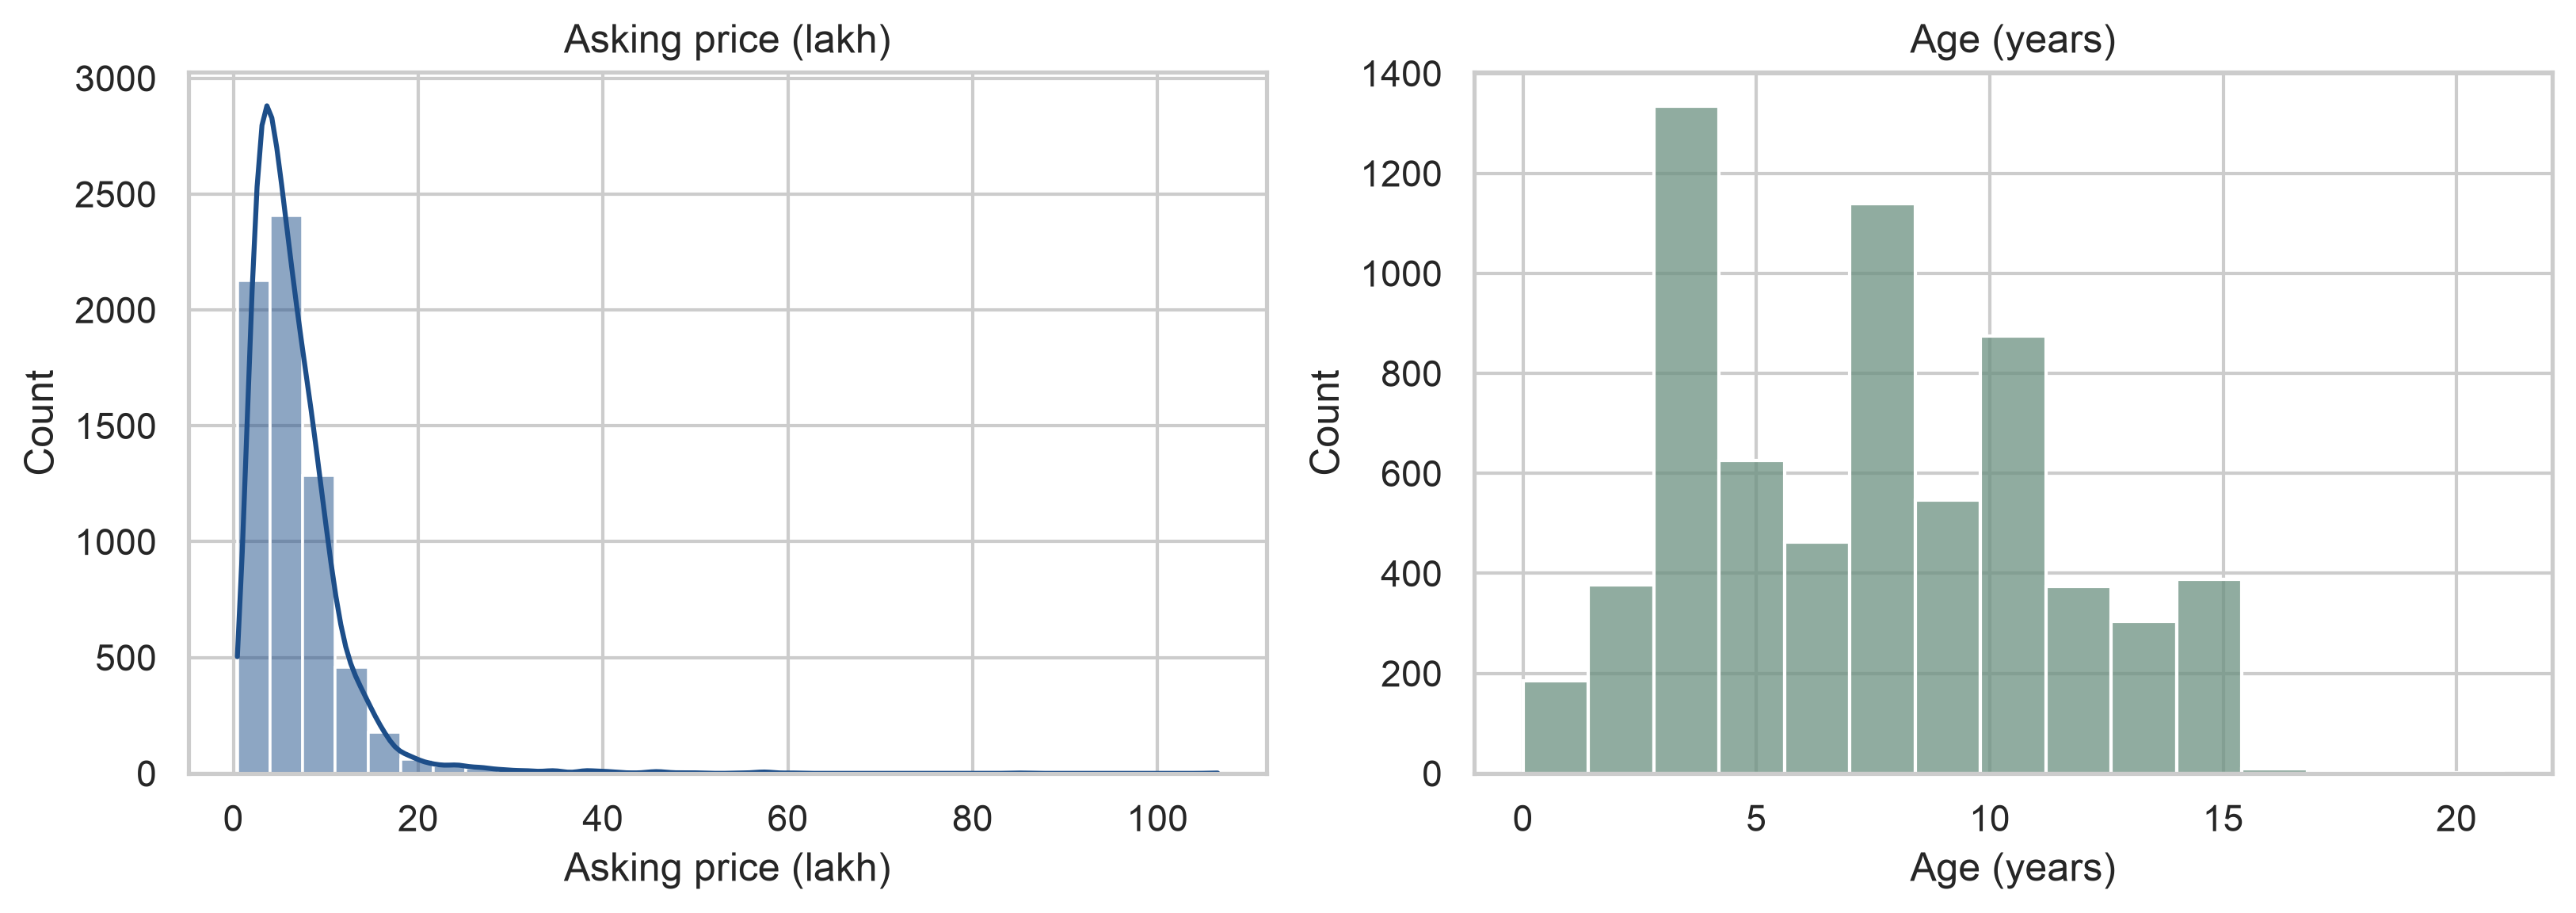

Mean price: 6.69 median: 5.5


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df["asking_price_lakh"], bins=30, kde=True, ax=axes[0], color="#1d4e89")
axes[0].set_title("Asking price (lakh)")
axes[0].set_xlabel("Asking price (lakh)")
sns.histplot(df["age_years"], bins=15, ax=axes[1], color="#6b9080")
axes[1].set_title("Age (years)")
axes[1].set_xlabel("Age (years)")
plt.tight_layout()
fig.savefig(FIG / "01_price_age_dist.png", bbox_inches="tight")
plt.show()
print("Mean price:", round(df["asking_price_lakh"].mean(), 2),
      "median:", round(df["asking_price_lakh"].median(), 2))


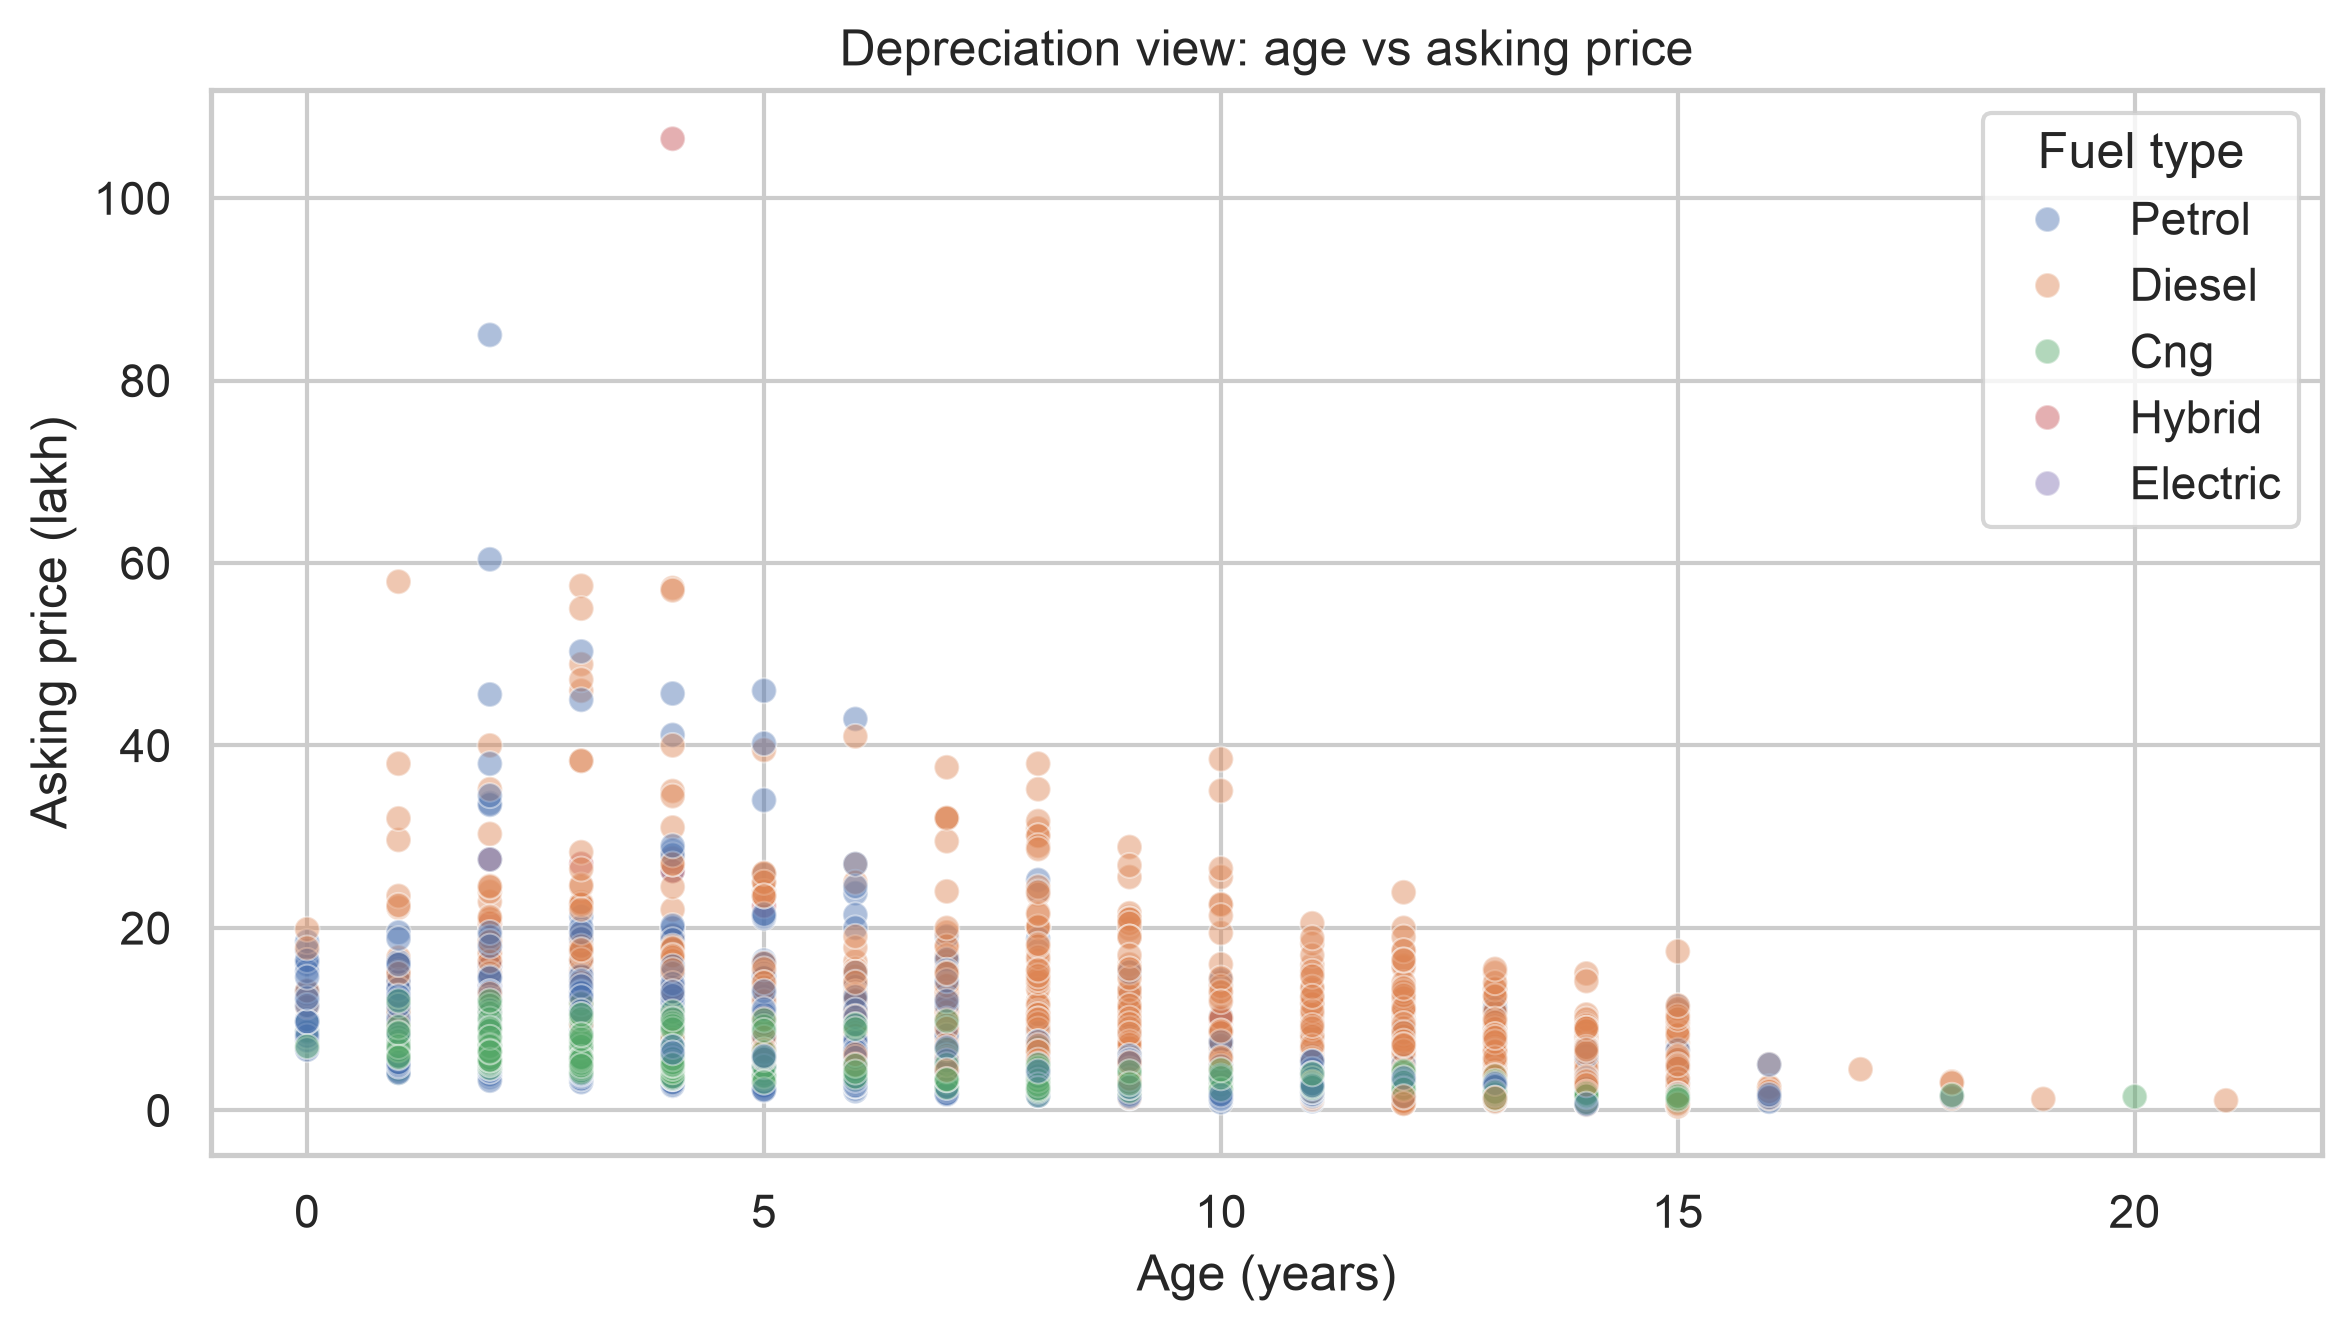

Correlation age vs price: -0.455


In [7]:
fig, ax = plt.subplots(figsize=(8, 4.6))
sns.scatterplot(data=df, x="age_years", y="asking_price_lakh", hue="fuel_type",
                hue_order=FUEL_ORDER, palette=FUEL_COLORS, alpha=0.45, ax=ax)
ax.set_title("Depreciation view: age vs asking price")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Asking price (lakh)")
ax.legend(title="Fuel type")
plt.tight_layout()
fig.savefig(FIG / "02_age_vs_price.png", bbox_inches="tight")
plt.show()
print("Correlation age vs price:", round(df["age_years"].corr(df["asking_price_lakh"]), 3))


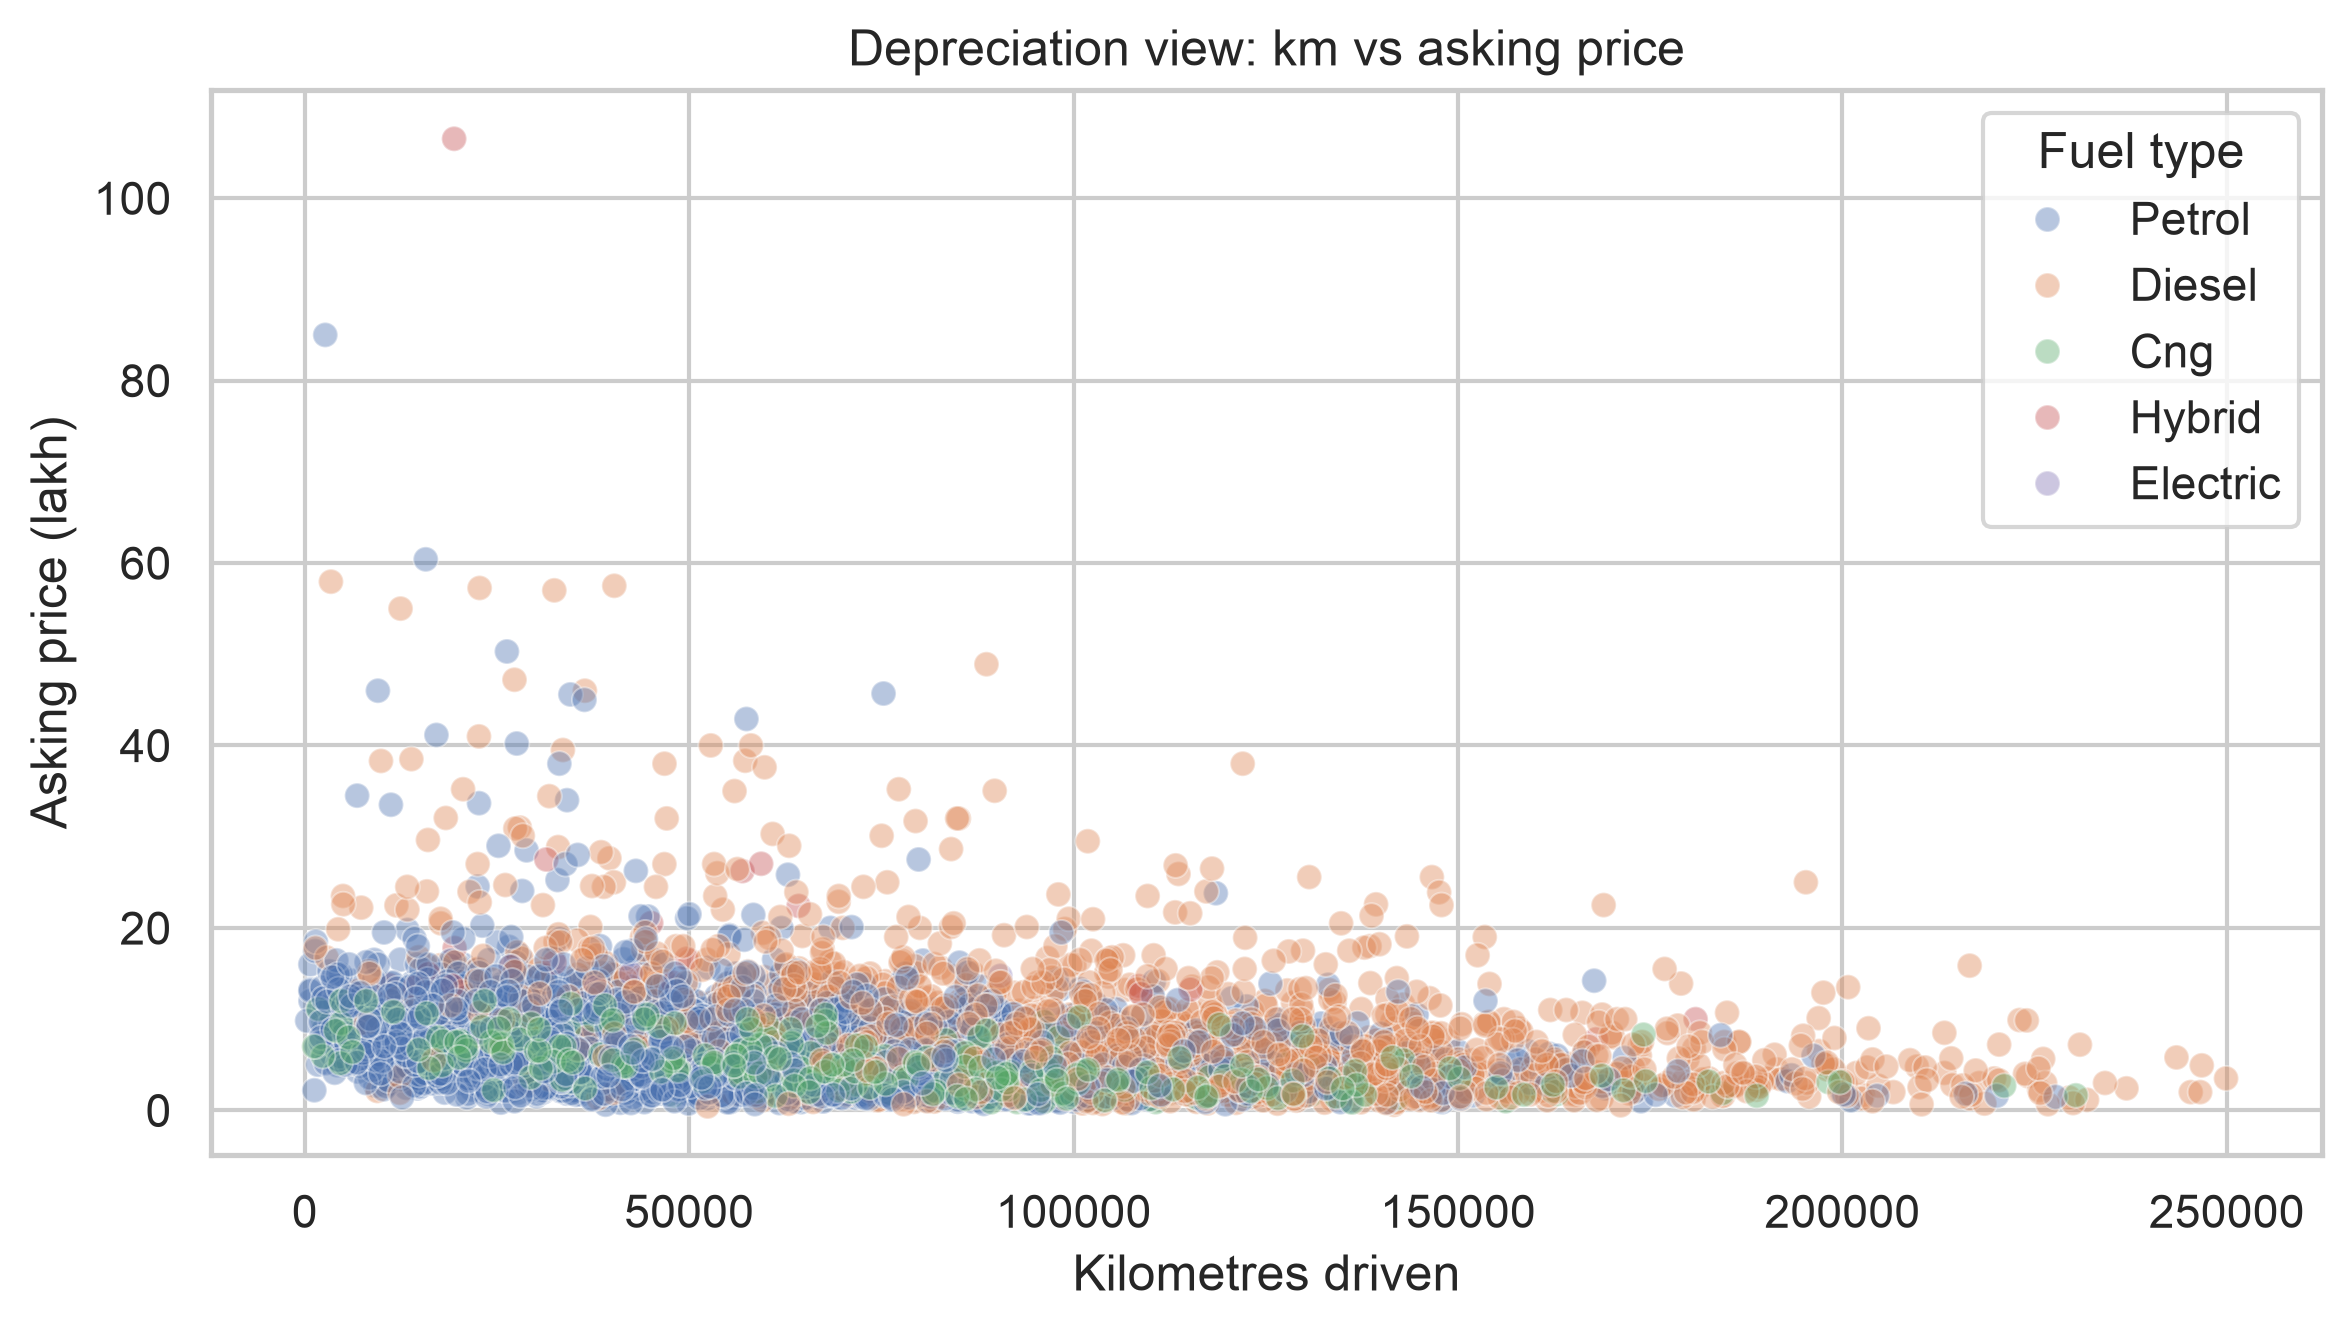

Correlation km vs price: -0.229


In [8]:
fig, ax = plt.subplots(figsize=(8, 4.6))
sns.scatterplot(data=df, x="km_driven", y="asking_price_lakh", hue="fuel_type",
                hue_order=FUEL_ORDER, palette=FUEL_COLORS, alpha=0.4, ax=ax)
ax.set_title("Depreciation view: km vs asking price")
ax.set_xlabel("Kilometres driven")
ax.set_ylabel("Asking price (lakh)")
ax.legend(title="Fuel type")
plt.tight_layout()
fig.savefig(FIG / "03_km_vs_price.png", bbox_inches="tight")
plt.show()
print("Correlation km vs price:", round(df["km_driven"].corr(df["asking_price_lakh"]), 3))


In [9]:
age_band = pd.cut(df["age_years"], bins=[-0.1, 5, 10, 25],
                  labels=["Young (0-5 yrs)", "Mid (6-10 yrs)", "Older (11+ yrs)"])
km_band = pd.cut(df["km_driven"], bins=[0, 50000, 90000, 1_000_000],
                 labels=["Low km (<=50k)", "Mid km (50-90k)", "High km (>90k)"])
age_km = (
    df.assign(age_band=age_band, km_band=km_band)
    .groupby(["age_band", "km_band"], observed=True)["asking_price_lakh"]
    .agg(["count", "median"])
    .round(2)
)
print("Median asking price (lakh) by age and kilometres")
print(age_km)
print("\nYoung + high km vs older + low km:")
print(age_km.loc[[("Young (0-5 yrs)", "High km (>90k)"),
                  ("Older (11+ yrs)", "Low km (<=50k)")]])

Median asking price (lakh) by age and kilometres
                                 count  median
age_band        km_band                       
Young (0-5 yrs) Low km (<=50k)    1449    8.50
                Mid km (50-90k)    813    7.70
                High km (>90k)     260    7.96
Mid (6-10 yrs)  Low km (<=50k)     550    4.56
                Mid km (50-90k)   1167    4.70
                High km (>90k)     921    4.99
Older (11+ yrs) Low km (<=50k)     142    2.90
                Mid km (50-90k)    504    2.80
                High km (>90k)     823    2.80

Young + high km vs older + low km:
                                count  median
age_band        km_band                      
Young (0-5 yrs) High km (>90k)    260    7.96
Older (11+ yrs) Low km (<=50k)    142    2.90


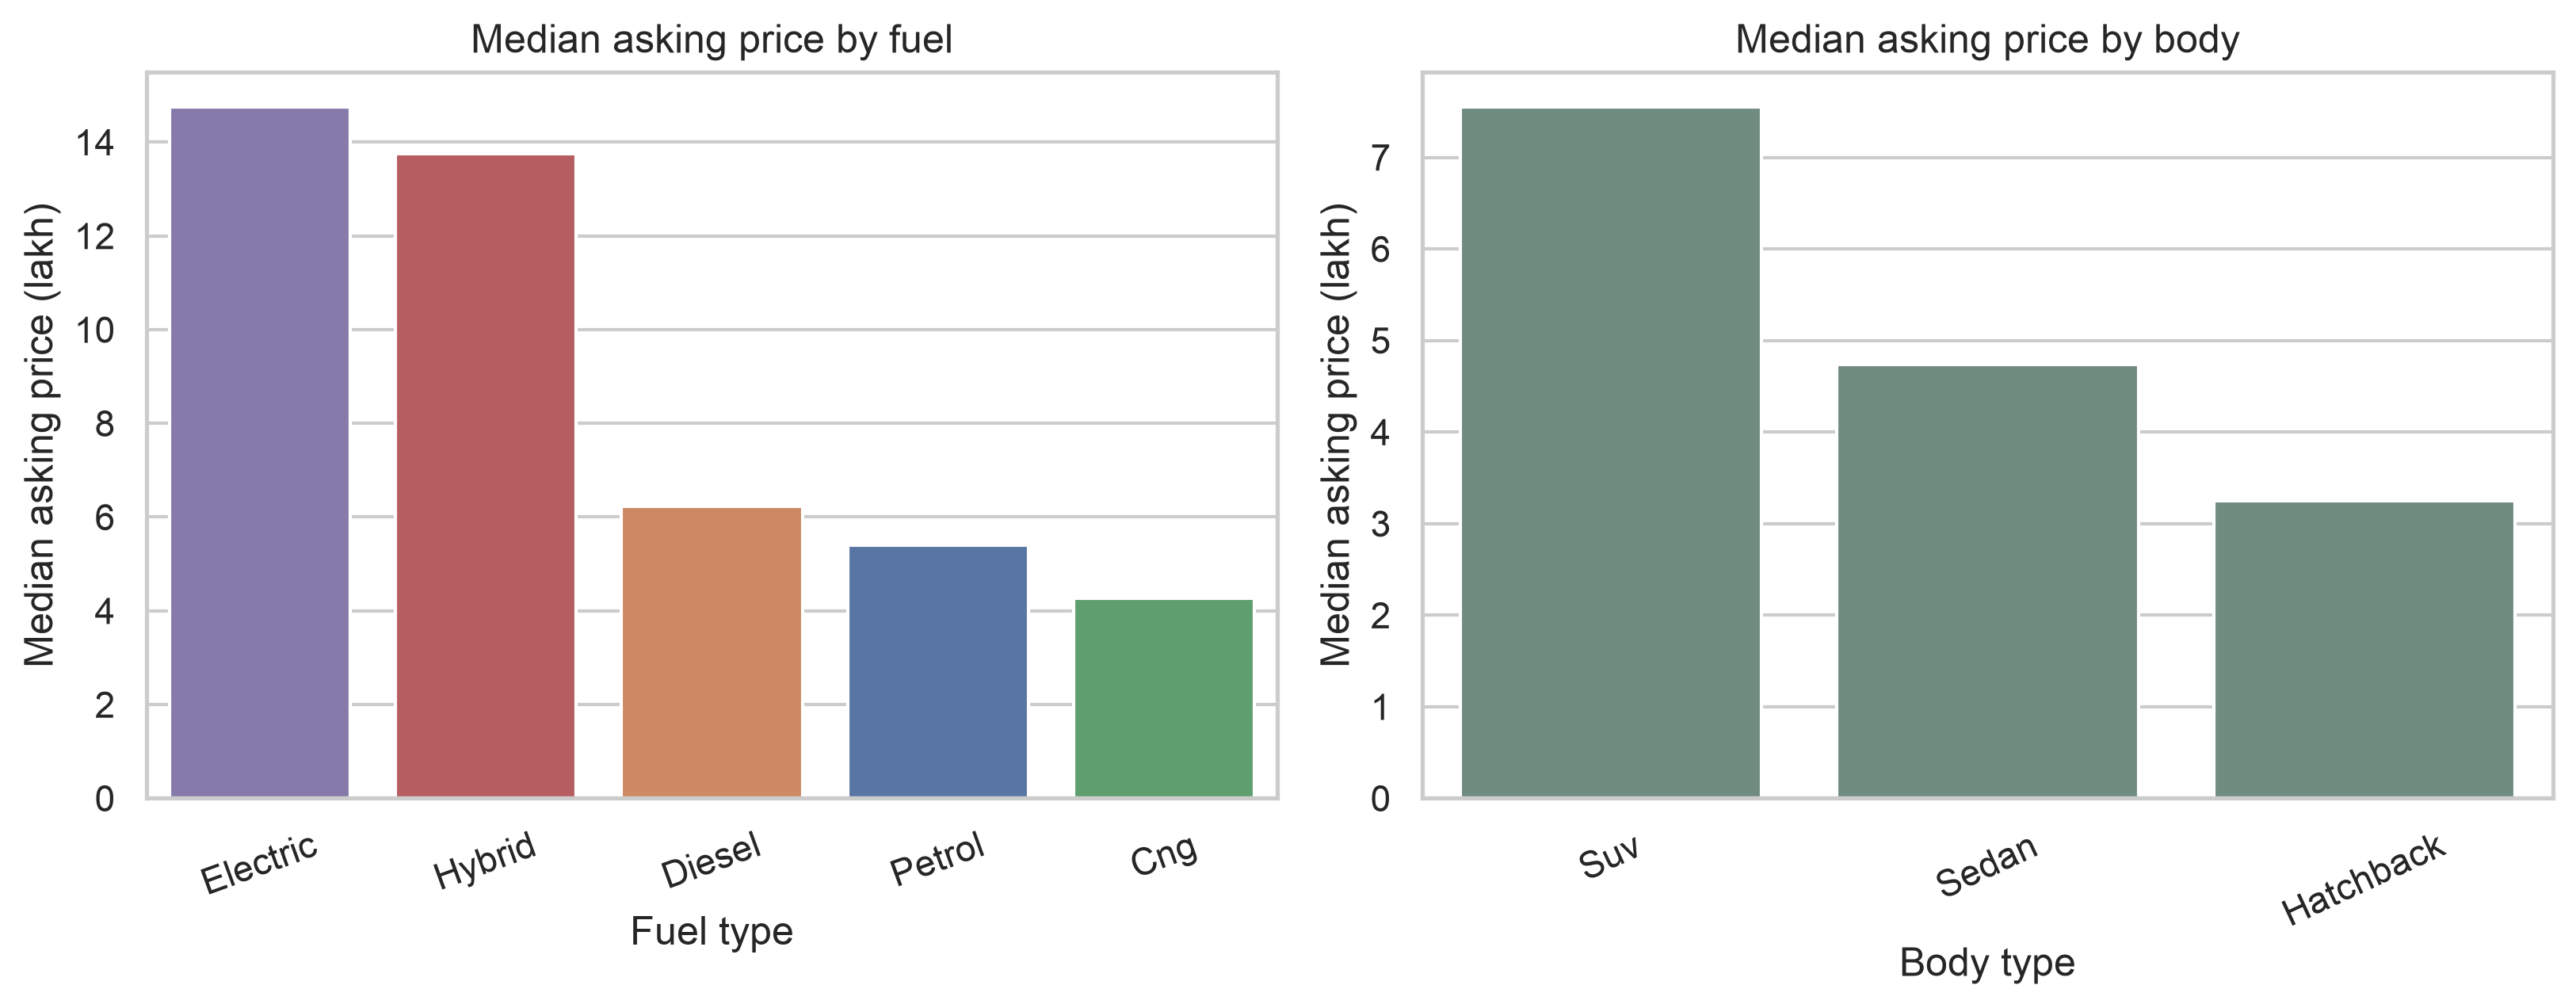

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
order_f = df.groupby("fuel_type")["asking_price_lakh"].median().sort_values(ascending=False).index
sns.barplot(data=df, x="fuel_type", y="asking_price_lakh", order=order_f,
            estimator="median", errorbar=None, ax=axes[0], palette=FUEL_COLORS)
axes[0].set_title("Median asking price by fuel")
axes[0].set_xlabel("Fuel type")
axes[0].set_ylabel("Median asking price (lakh)")
axes[0].tick_params(axis="x", rotation=20)
order_b = df.groupby("body_type")["asking_price_lakh"].median().sort_values(ascending=False).index
sns.barplot(data=df, x="body_type", y="asking_price_lakh", order=order_b,
            estimator="median", errorbar=None, ax=axes[1], color="#6b9080")
axes[1].set_title("Median asking price by body")
axes[1].set_xlabel("Body type")
axes[1].set_ylabel("Median asking price (lakh)")
axes[1].tick_params(axis="x", rotation=25)
plt.tight_layout()
fig.savefig(FIG / "04_price_by_fuel_body.png", bbox_inches="tight")
plt.show()


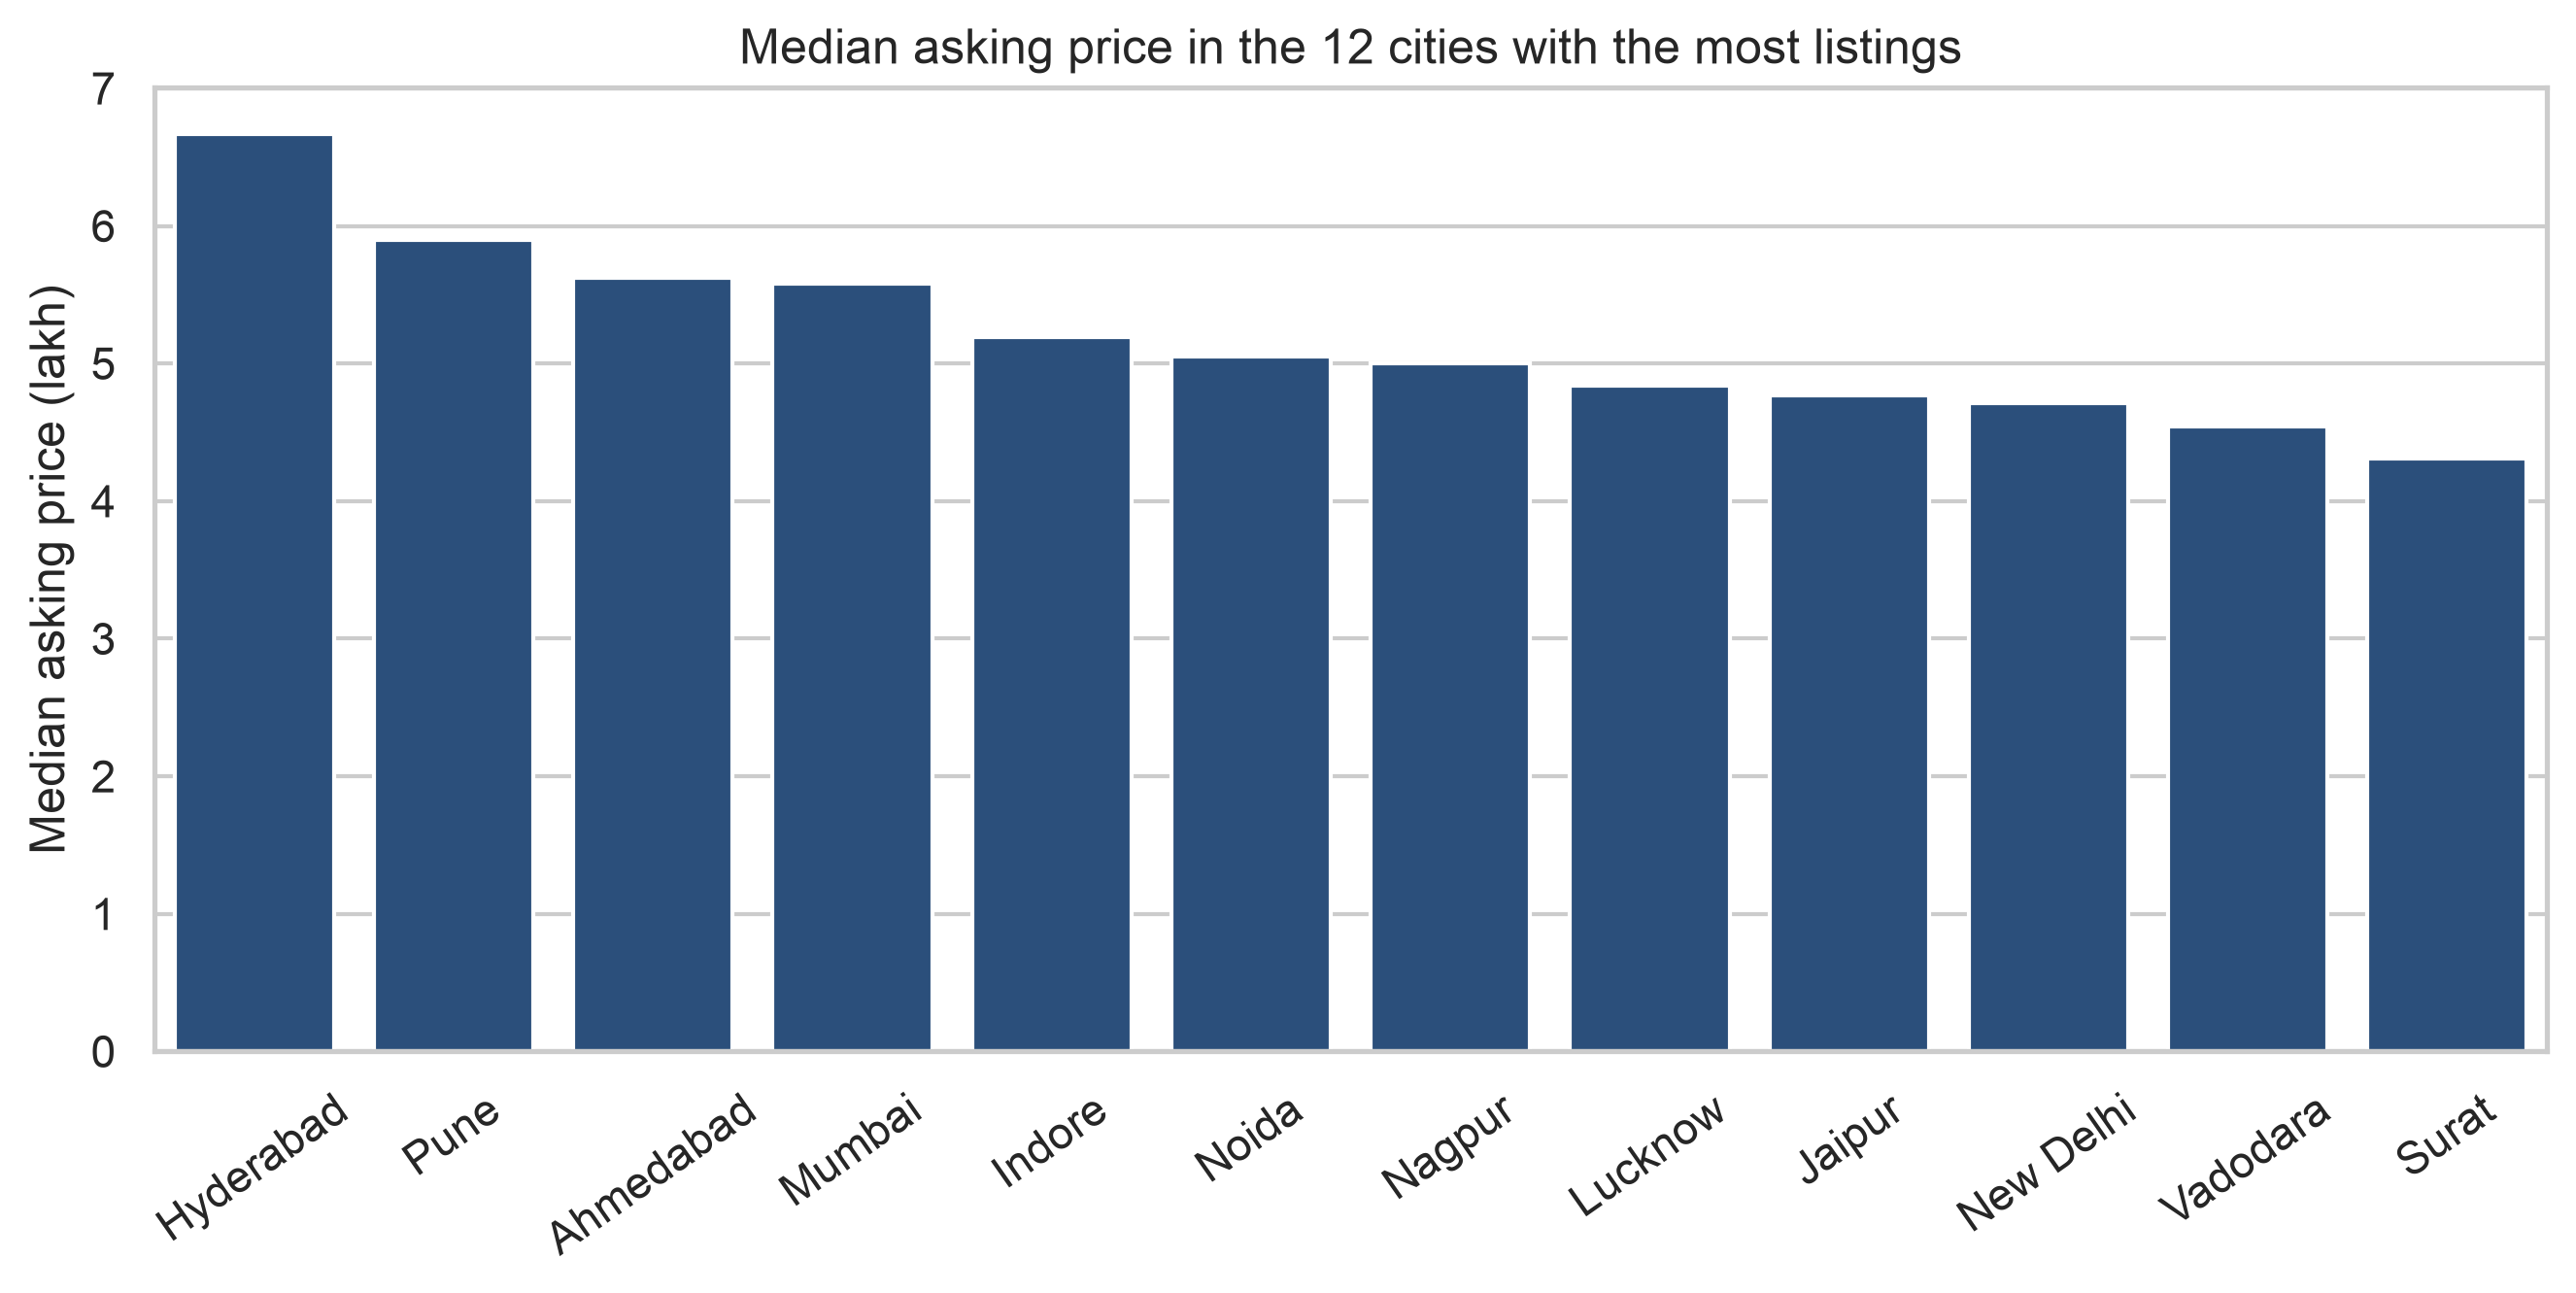

           count  median
city                    
Hyderabad    306    6.67
Pune         297    5.90
Ahmedabad    290    5.62
Mumbai       221    5.58
Indore       213    5.19
Noida        210    5.05
Nagpur       250    5.00
Lucknow      257    4.84
Jaipur       259    4.77
New Delhi    312    4.71
Vadodara     230    4.54
Surat        261    4.31


In [11]:
city = (
    df.dropna(subset=["city"])
    .groupby("city")["asking_price_lakh"]
    .agg(["count", "median"])
    .sort_values("count", ascending=False)
    .head(12)
    .sort_values("median", ascending=False)
)
fig, ax = plt.subplots(figsize=(9, 4.6))
sns.barplot(x=city.index, y=city["median"], ax=ax, color="#1d4e89")
ax.set_ylabel("Median asking price (lakh)")
ax.set_xlabel("")
ax.set_title("Median asking price in the 12 cities with the most listings")
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
fig.savefig(FIG / "08_price_by_city.png", bbox_inches="tight")
plt.show()
print(city.round(2))

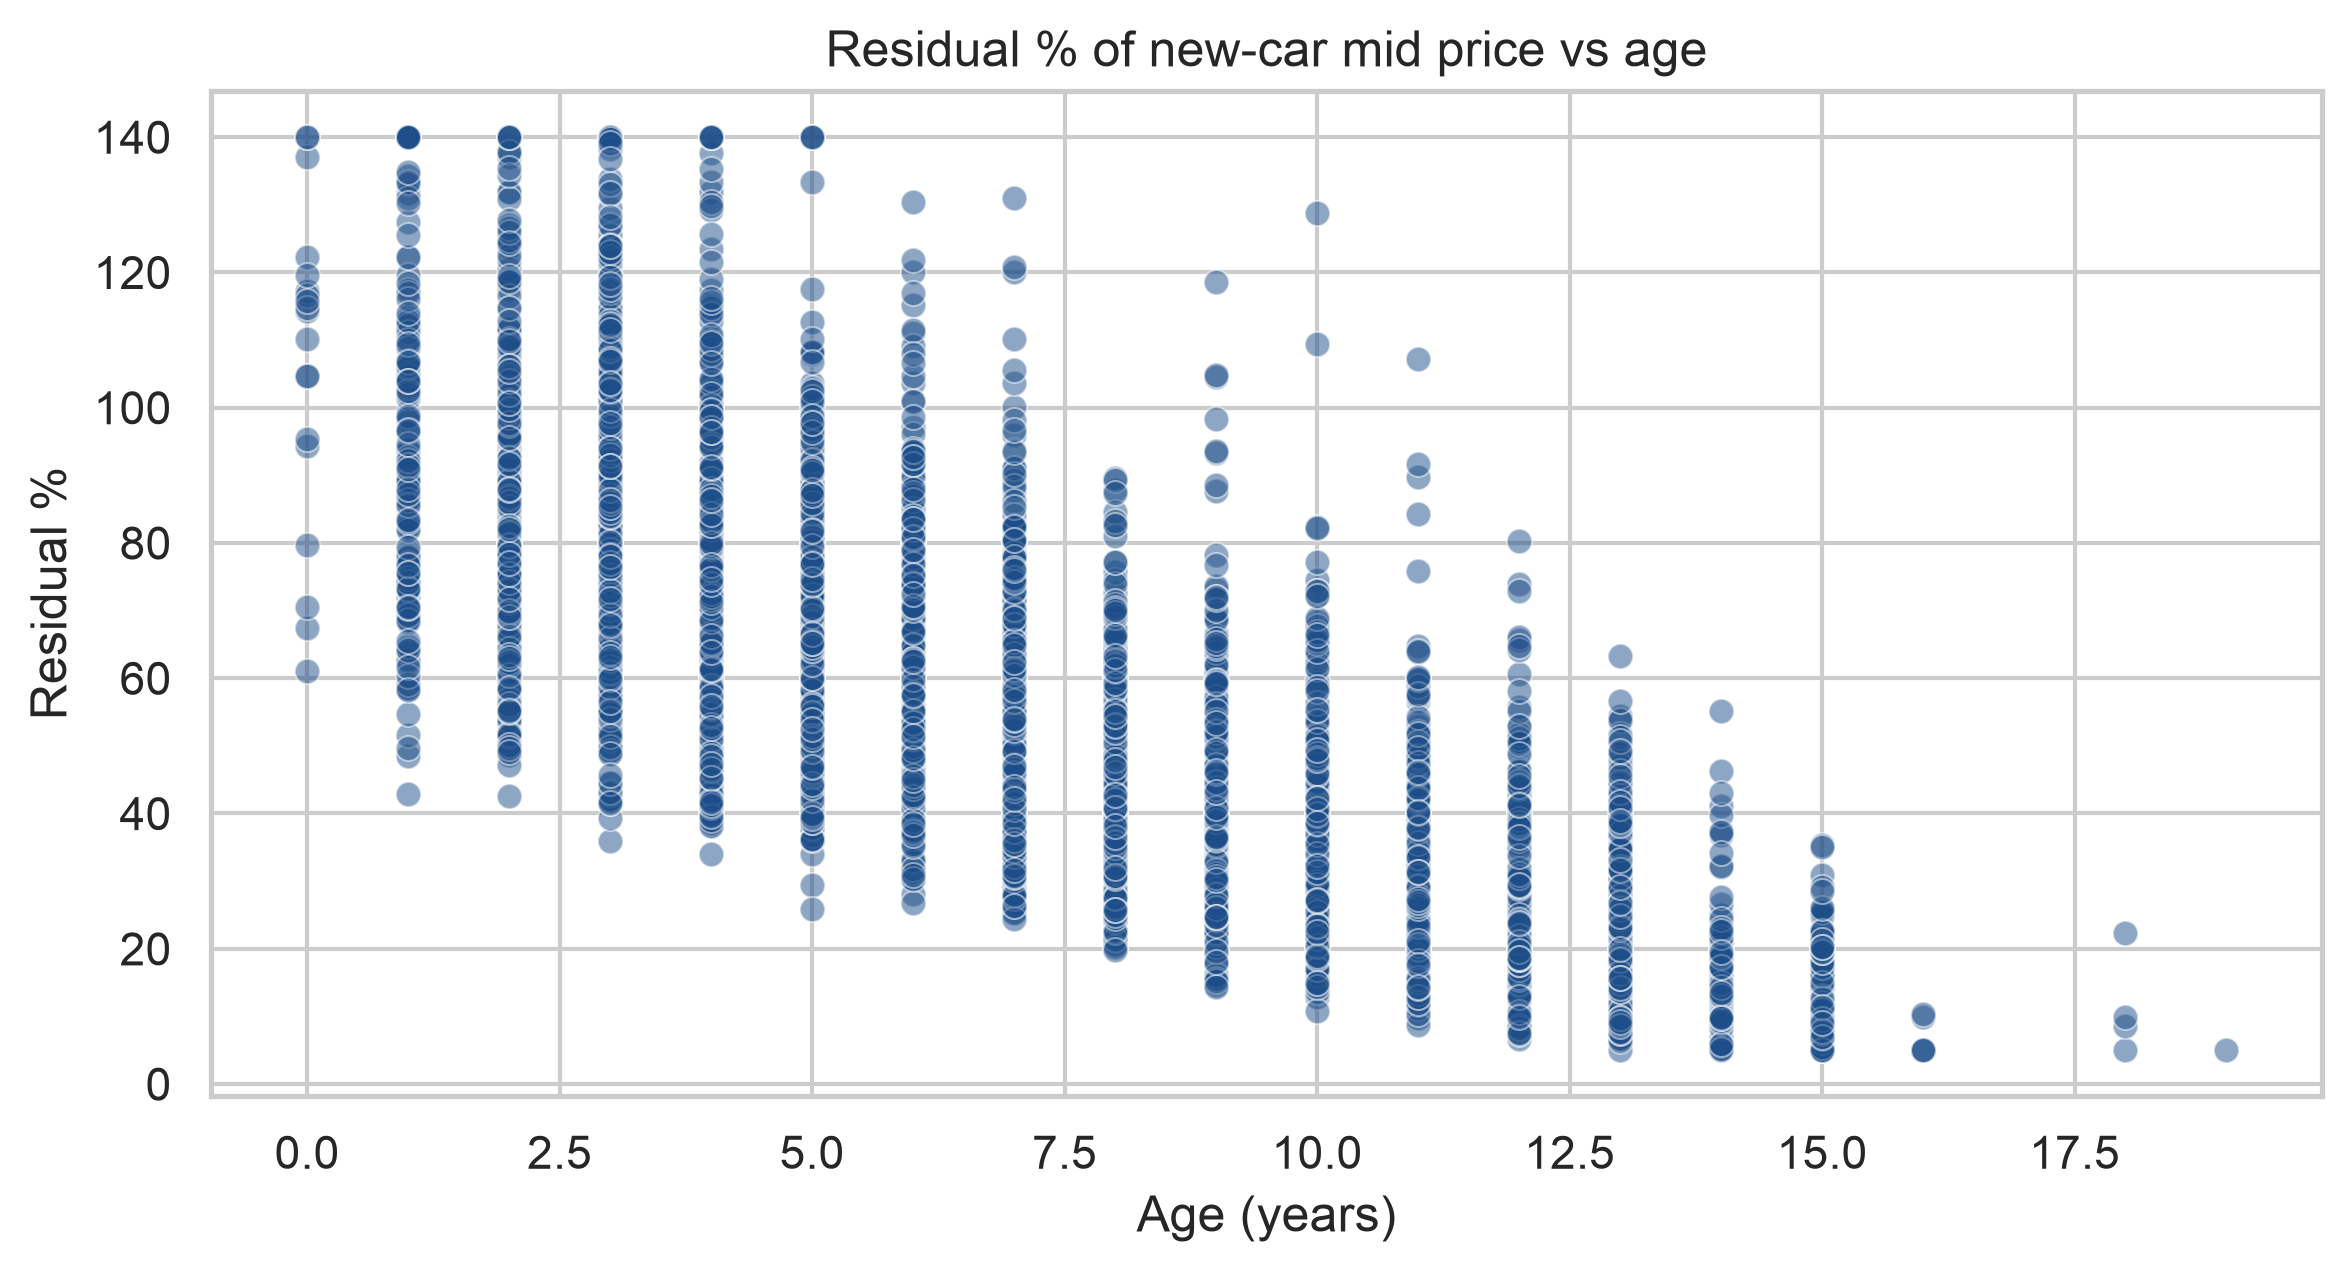

Median residual %: 58.2 n= 4392

Residual % by selected brand:
                 n  residual_med  ask_med  age_med
brand                                             
KIA            430         83.48     9.11      4.0
Mahindra       237         83.47    11.00      4.0
Maruti         499         59.19     3.71      9.0
Honda          420         39.88     4.40      9.0
Hyundai        294         38.26     6.16      8.0
BMW            111         18.28    13.50     12.0
Mercedes Benz   88         16.24    12.45     11.0
Audi            88         13.18     7.60     13.0


In [12]:
res = df.dropna(subset=["residual_pct"])
if len(res) >= 30:
    fig, ax = plt.subplots(figsize=(8, 4.4))
    sns.scatterplot(data=res, x="age_years", y="residual_pct", alpha=0.5, ax=ax, color="#1d4e89")
    ax.set_title("Residual % of new-car mid price vs age")
    ax.set_xlabel("Age (years)")
    ax.set_ylabel("Residual %")
    plt.tight_layout()
    fig.savefig(FIG / "05_residual_vs_age.png", bbox_inches="tight")
    plt.show()
    print("Median residual %:", round(res["residual_pct"].median(), 1), "n=", len(res))
    brand_res = (
        res.groupby("brand")
        .agg(n=("residual_pct", "count"),
             residual_med=("residual_pct", "median"),
             ask_med=("asking_price_lakh", "median"),
             age_med=("age_years", "median"))
    )
    keep = ["KIA", "Mahindra", "Maruti", "Honda", "Hyundai", "BMW", "Mercedes Benz", "Audi"]
    brand_res = brand_res.reindex([b for b in keep if b in brand_res.index]).round(2)
    print("\nResidual % by selected brand:")
    print(brand_res)
else:
    print("Not enough joined residual rows to plot.")

## 6. Predictive models

**Predict:** `asking_price_lakh`  
**From:** age, km, owners, fuel, transmission, body, brand, city.

All models use the same 80/20 split and five-fold cross-validation:

1. **Linear Regression** — interpretable baseline for additive, approximately linear effects.
2. **Decision Tree** — captures non-linear thresholds and interactions; depth is limited to reduce overfitting.
3. **Random Forest** — averages 280 trees to improve stability and capture more complex price patterns.

The models are compared using R², MAE, RMSE and cross-validation R². **Random Forest is selected as the best/final model because it performs best on every reported metric.**

In [13]:
feature_num = ["age_years", "km_driven", "ownership"]
feature_cat = ["fuel_type", "transmission", "body_type", "brand"]
if df["city"].nunique() >= 4:
    feature_cat = feature_cat + ["city"]

model_df = df[feature_num + feature_cat + ["asking_price_lakh"]].copy()
model_df = model_df.dropna(subset=["asking_price_lakh", "age_years", "km_driven"])
print("Modelling rows:", len(model_df))

X = model_df[feature_num + feature_cat]
y = model_df["asking_price_lakh"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print("Train:", X_train.shape, "Test:", X_test.shape)

prep = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), feature_num),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("oh", OneHotEncoder(handle_unknown="ignore")),
    ]), feature_cat),
])

Modelling rows: 6629
Train: (5303, 8) Test: (1326, 8)


In [14]:
def eval_model(name, estimator):
    pipe = Pipeline([("prep", prep), ("model", estimator)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    r2 = r2_score(y_test, pred)
    mae = mean_absolute_error(y_test, pred)
    rmse = mean_squared_error(y_test, pred) ** 0.5
    cv_splitter = KFold(n_splits=5, shuffle=True, random_state=42)
    cv = cross_val_score(pipe, X_train, y_train, cv=cv_splitter, scoring="r2")
    print(f"{name:22s}  R2={r2:6.3f}  MAE={mae:6.3f}  RMSE={rmse:6.3f}  "
          f"CV-R2={cv.mean():6.3f} (±{cv.std():.3f})")
    return pipe, pred, {"model": name, "R2": r2, "MAE": mae, "RMSE": rmse, "CV_R2": cv.mean()}

lr_pipe, lr_pred, lr_m = eval_model("Linear Regression", LinearRegression())
dt_pipe, dt_pred, dt_m = eval_model("Decision Tree", DecisionTreeRegressor(max_depth=8, random_state=42))
rf_pipe, rf_pred, rf_m = eval_model("Random Forest", RandomForestRegressor(
    n_estimators=280, max_depth=14, min_samples_leaf=2, random_state=42, n_jobs=-1
))
print(pd.DataFrame([lr_m, dt_m, rf_m]).round(3))
print("Submitted model: Random Forest")

Linear Regression       R2= 0.668  MAE= 1.827  RMSE= 2.914  CV-R2= 0.609 (±0.029)


Decision Tree           R2= 0.716  MAE= 1.662  RMSE= 2.695  CV-R2= 0.664 (±0.064)


Random Forest           R2= 0.800  MAE= 1.379  RMSE= 2.262  CV-R2= 0.777 (±0.040)
               model     R2    MAE   RMSE  CV_R2
0  Linear Regression  0.668  1.827  2.914  0.609
1      Decision Tree  0.716  1.662  2.695  0.664
2      Random Forest  0.800  1.379  2.262  0.777
Submitted model: Random Forest


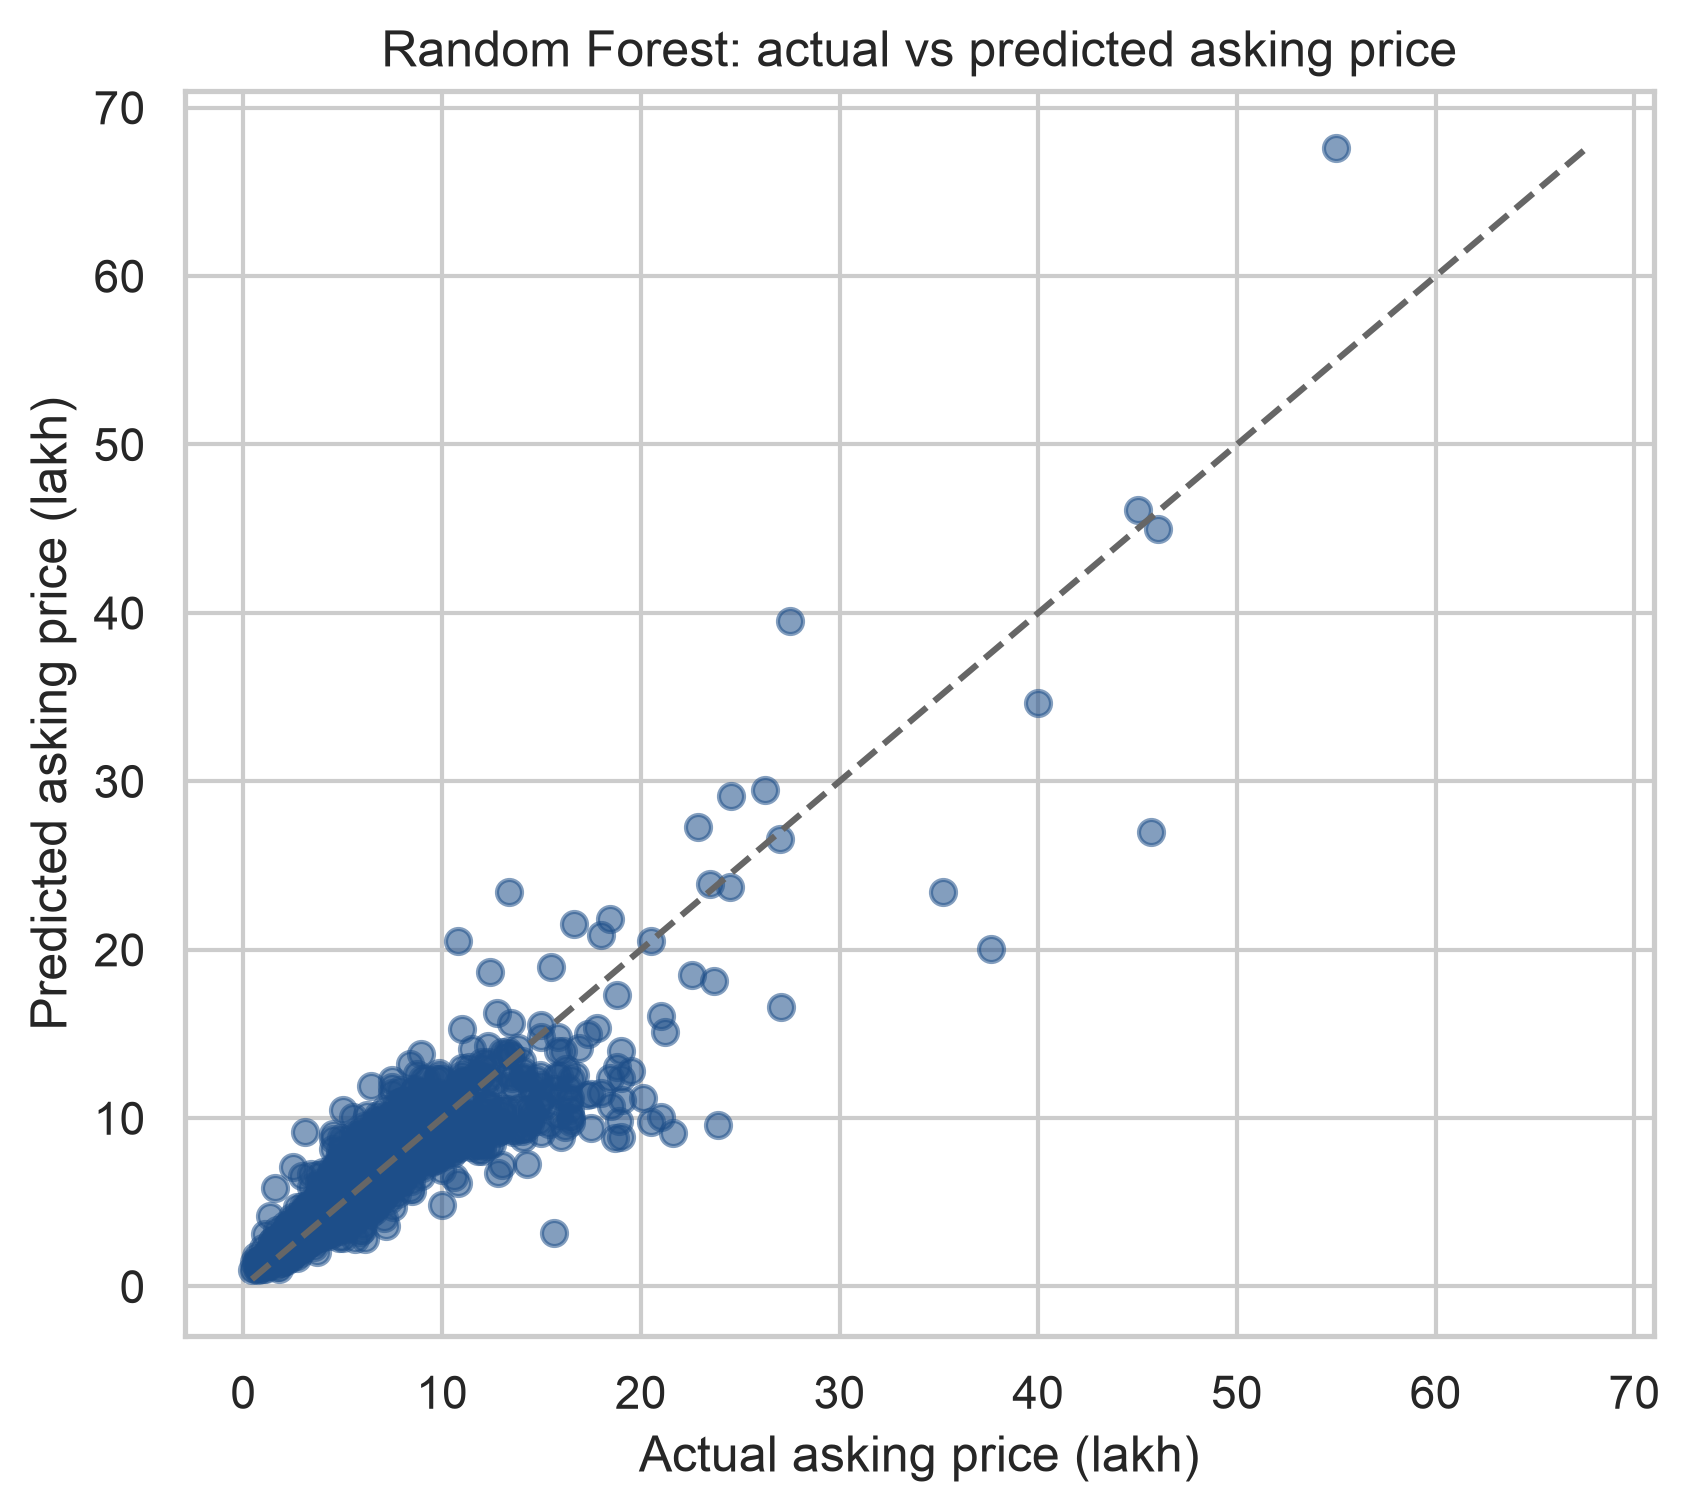

In [15]:
fig, ax = plt.subplots(figsize=(5.8, 5.2))
ax.scatter(y_test, rf_pred, alpha=0.55, color="#1d4e89")
lo, hi = float(min(y_test.min(), rf_pred.min())), float(max(y_test.max(), rf_pred.max()))
ax.plot([lo, hi], [lo, hi], "--", color="0.4")
ax.set_title("Random Forest: actual vs predicted asking price")
ax.set_xlabel("Actual asking price (lakh)")
ax.set_ylabel("Predicted asking price (lakh)")
plt.tight_layout()
fig.savefig(FIG / "06_rf_actual_vs_pred.png", bbox_inches="tight")
plt.show()

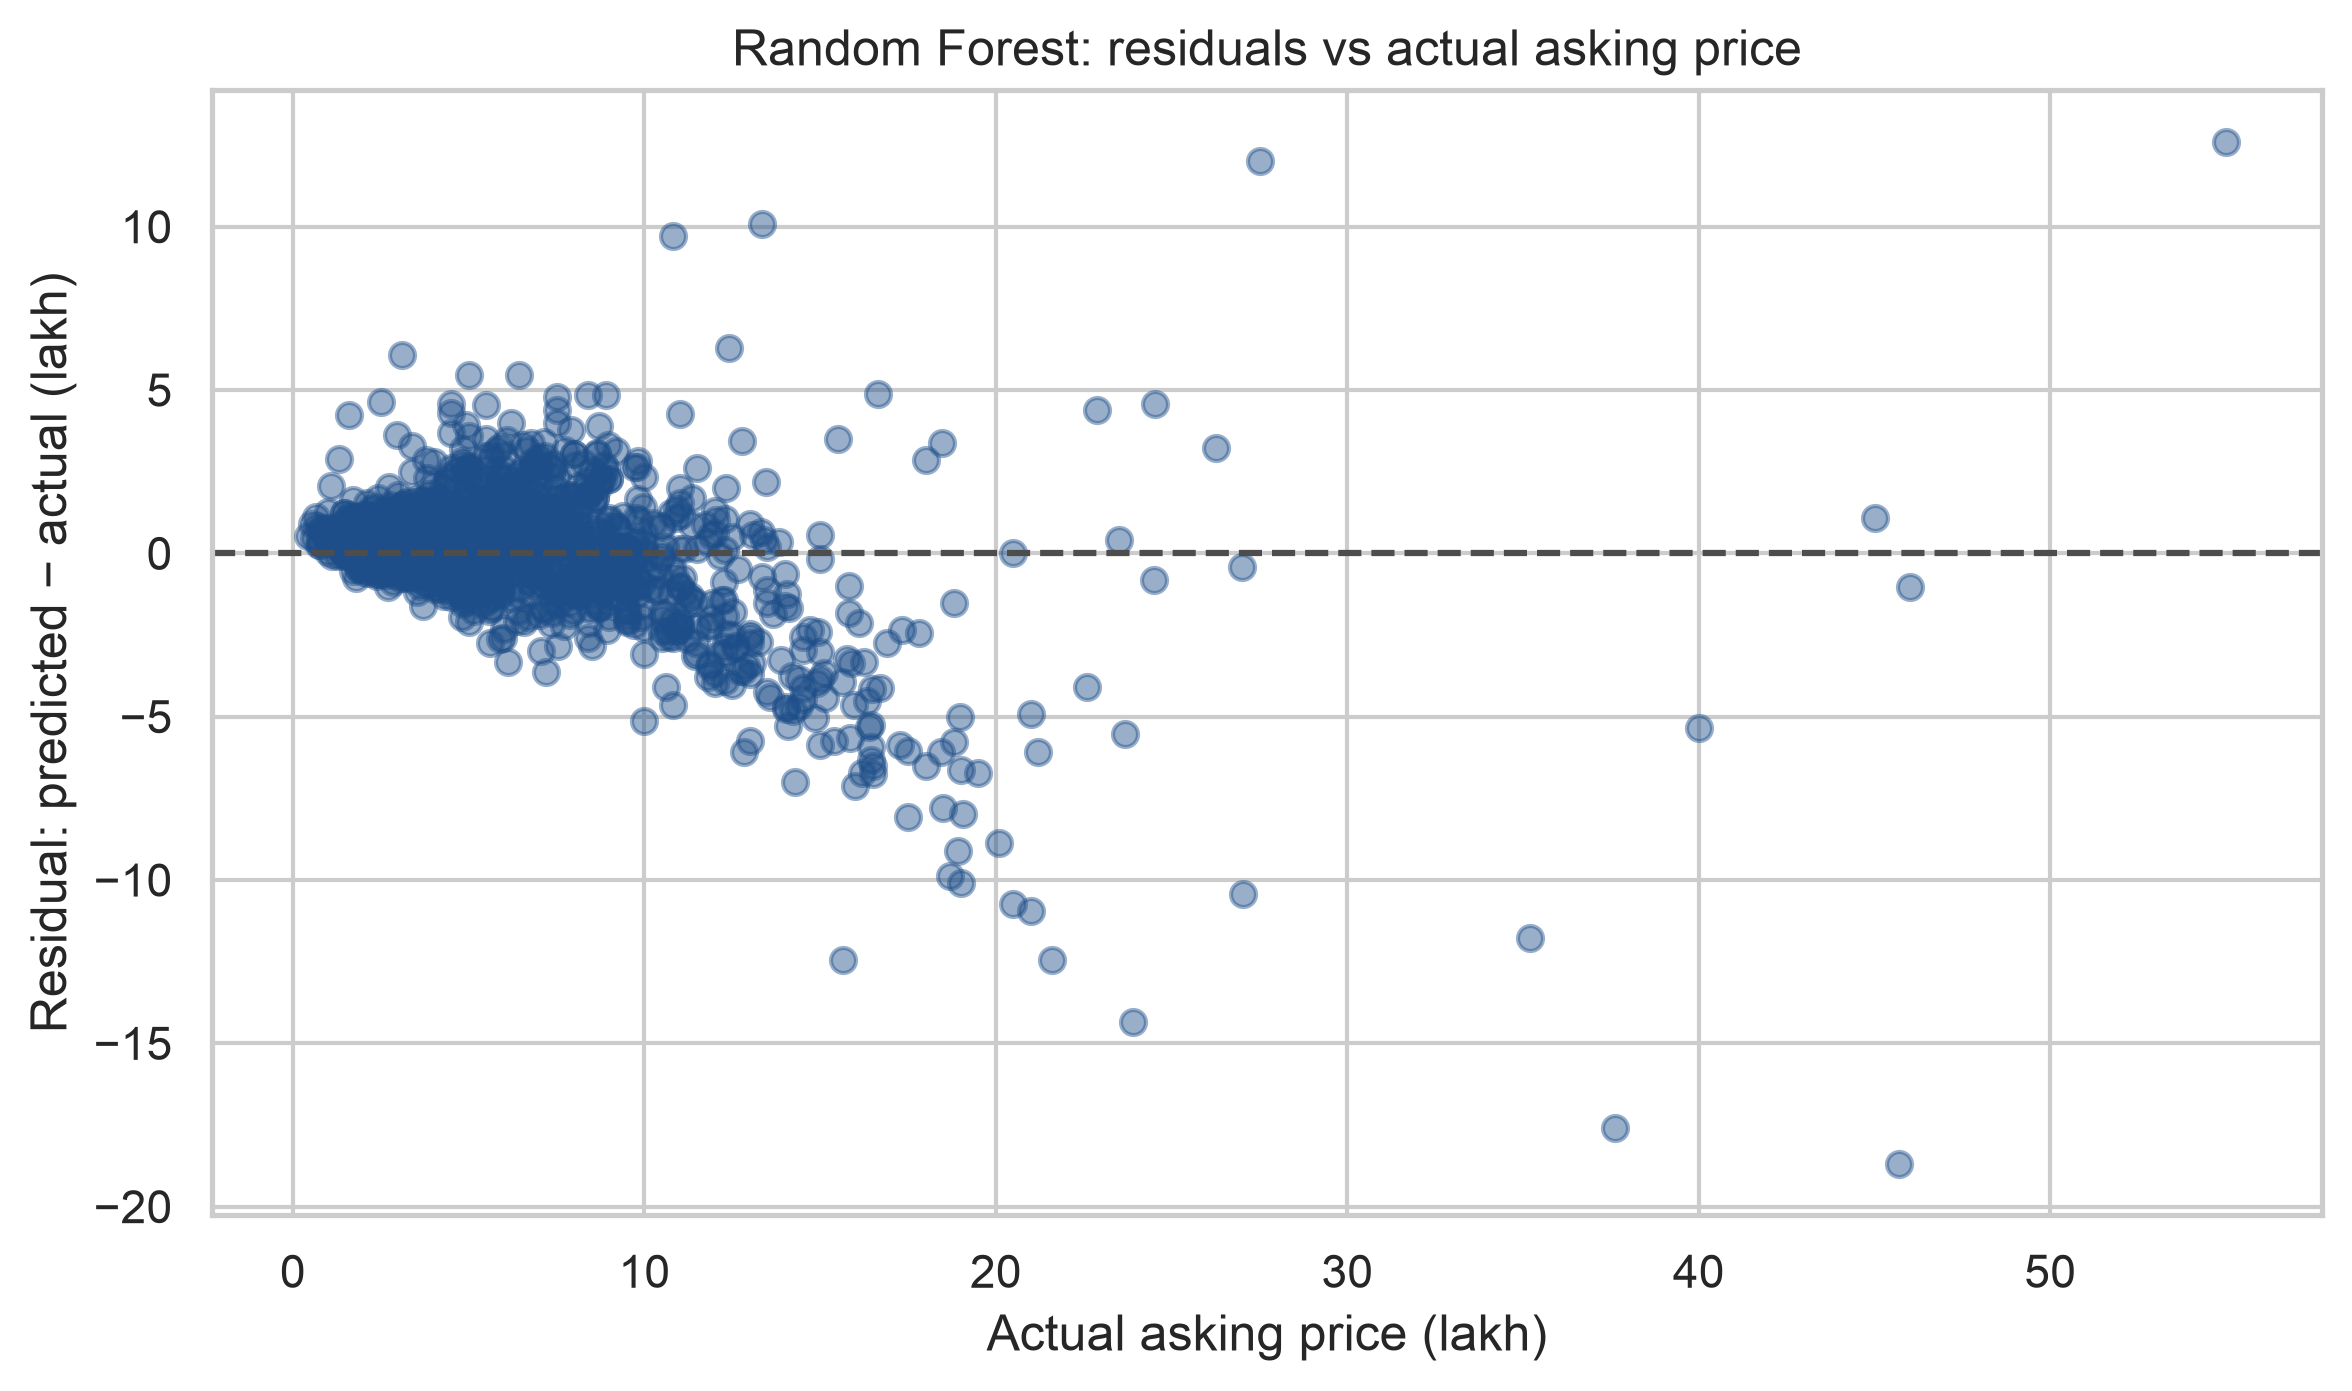

Residual mean: -0.061
Residual std (actual < 15 lakh): 1.563
Residual std (actual >= 15 lakh): 5.415
Ratio high/low std: 3.47


In [16]:
resid = rf_pred - y_test.values
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.scatter(y_test, resid, alpha=0.45, color="#1d4e89")
ax.axhline(0, color="0.3", linestyle="--")
ax.set_xlabel("Actual asking price (lakh)")
ax.set_ylabel("Residual: predicted \u2212 actual (lakh)")
ax.set_title("Random Forest: residuals vs actual asking price")
plt.tight_layout()
fig.savefig(FIG / "09_rf_residuals.png", bbox_inches="tight")
plt.show()

low_std = resid[y_test.values < 15].std()
high_std = resid[y_test.values >= 15].std()
print("Residual mean:", round(resid.mean(), 3))
print("Residual std (actual < 15 lakh):", round(low_std, 3))
print("Residual std (actual >= 15 lakh):", round(high_std, 3))
print("Ratio high/low std:", round(high_std / low_std, 2))


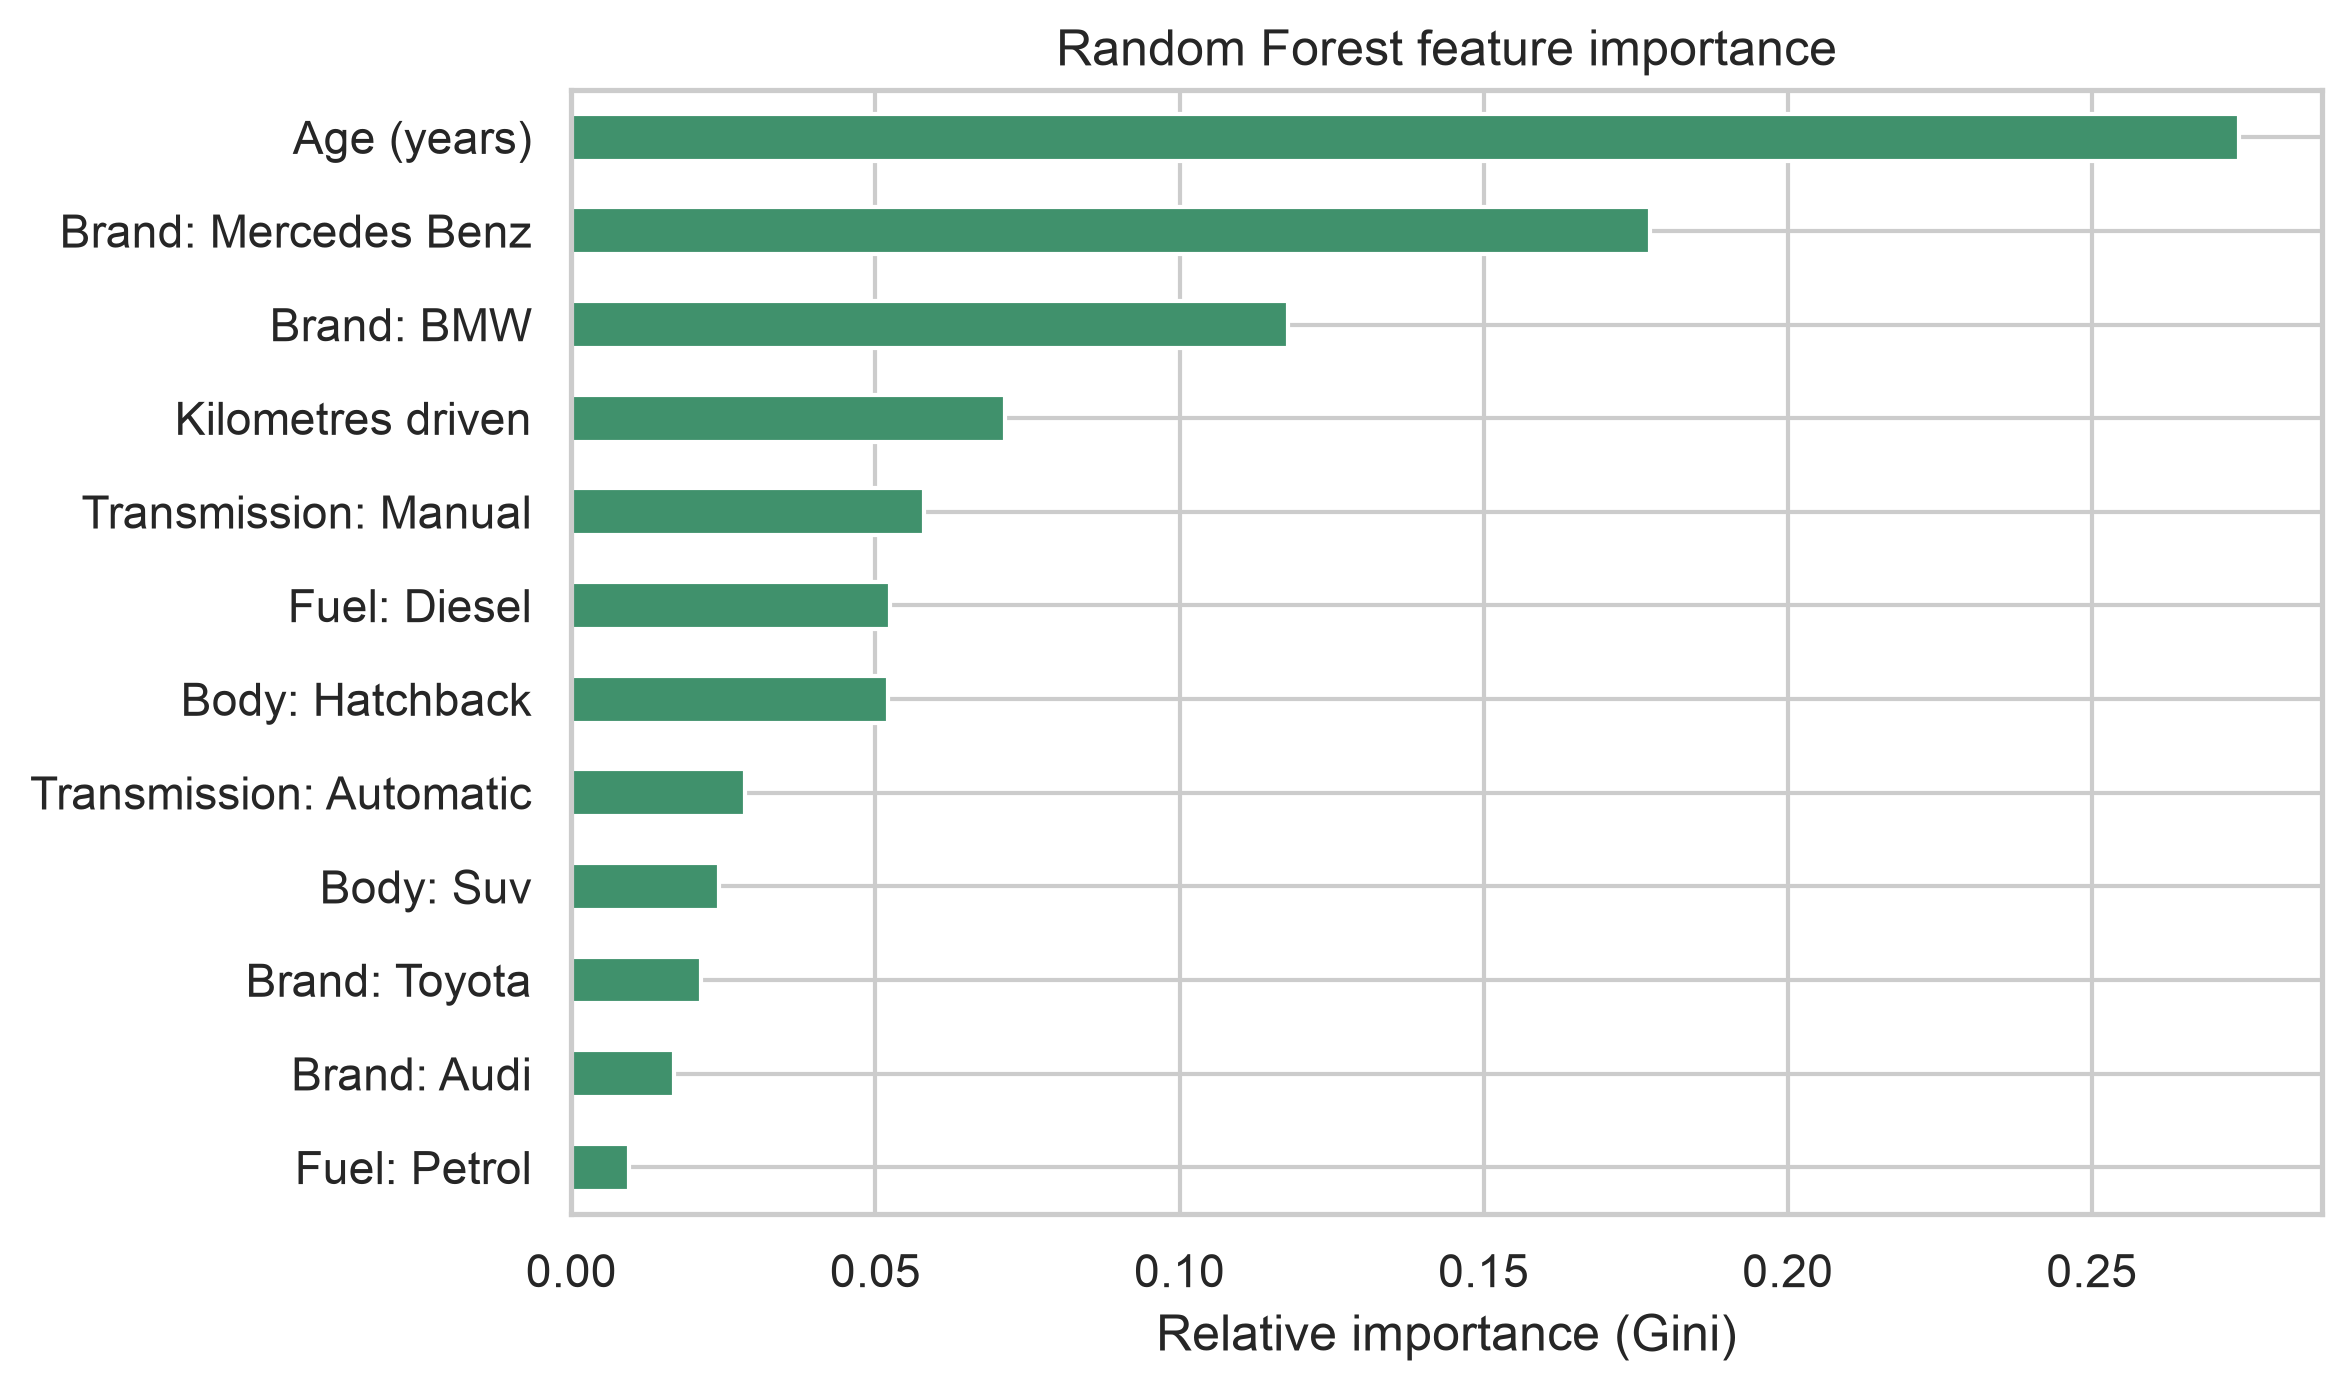

Age (years)                0.274
Brand: Mercedes Benz       0.177
Brand: BMW                 0.118
Kilometres driven          0.071
Transmission: Manual       0.058
Fuel: Diesel               0.052
Body: Hatchback            0.052
Transmission: Automatic    0.029
Body: Suv                  0.024
Brand: Toyota              0.021
Brand: Audi                0.017
Fuel: Petrol               0.010
dtype: float64


In [17]:
names = rf_pipe.named_steps["prep"].get_feature_names_out()
pretty_names = [prettify_feature(n) for n in names]
imp = pd.Series(rf_pipe.named_steps["model"].feature_importances_, index=pretty_names)
imp = imp.sort_values(ascending=False).head(12)
fig, ax = plt.subplots(figsize=(8, 4.8))
imp.sort_values().plot(kind="barh", ax=ax, color="#40916c")
ax.set_title("Random Forest feature importance")
ax.set_xlabel("Relative importance (Gini)")
plt.tight_layout()
fig.savefig(FIG / "07_feature_importance.png", bbox_inches="tight")
plt.show()
print(imp.round(3))


## 7. Insights and recommendations

1. Asking prices are spread out (mean 6.69 lakh, median 5.50), so a price model is usable rather than a single nearby ad.
2. Age (r = −0.46) and kilometres (r = −0.23) are the depreciation levers; read them together, not as one yearly cut.
3. Use the predicted price as a listing screen (typical miss about ₹1.38 lakh), then adjust for condition and papers.
4. Residual % (median 58% on 4,392 matched rows) shows which nameplates still hold a larger share of new price; it is not a model input.
5. City medians differ even among high-volume markets (Hyderabad vs Surat); do not copy a national sticker blindly.

## 8. Summary

| Stage | What was done |
|---|---|
| Collection | Same Cars24 pages via Python (6,693 unique) and Apify (6,766 unique); analysis uses Python |
| Preprocessing | Age, km/price filters, optional new-car residual join |
| Model | Predict `asking_price_lakh`; Random Forest submitted (test R² 0.800) |
| Output | `data/processed/used_cars.csv`, figures in `figures/` |
